In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_BASE_PATH = "../data/TP-Dataset/GroundTruth/"

In [2]:
def unwrap[T](obj: T | None, msg: str = "Unexpected None") -> T:
    if obj is None:
        raise ValueError(msg)
    return obj

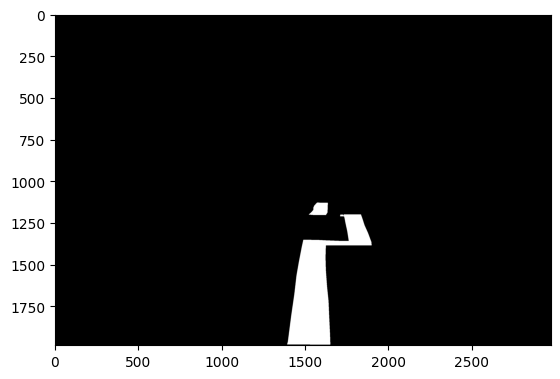

In [3]:
img = unwrap(cv2.imread(IMAGE_BASE_PATH + "Part01/0001.png"))

plt.imshow(img)

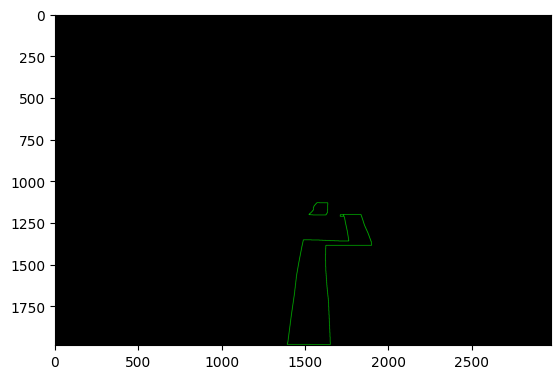

In [4]:
bin_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

contours, hierarchy = cv2.findContours(bin_img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

result = np.zeros_like(img)
cv2.drawContours(result, contours, -1, (0, 255, 0), 2)

plt.imshow(result)

Contour boundary (x_min, y_min, x_max, y_max): (np.int32(1390), np.int32(1130), np.int32(1895), np.int32(1981))


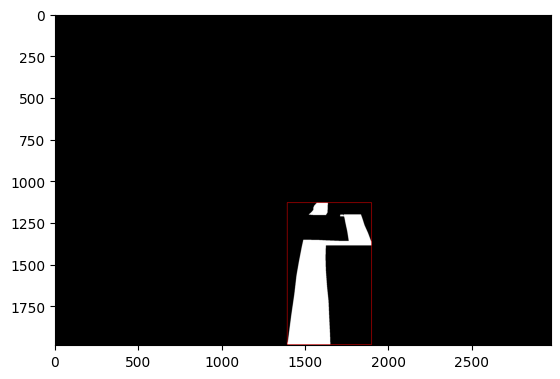

In [5]:
contour_points = np.vstack(contours)
contour_points_x = contour_points[:, 0, 0]
contour_points_y = contour_points[:, 0, 1]
contour_boundary = (
    min(contour_points_x),
    min(contour_points_y),
    max(contour_points_x),
    max(contour_points_y),
)

print("Contour boundary (x_min, y_min, x_max, y_max):", contour_boundary)

x_min, y_min, x_max, y_max = contour_boundary
img_with_box = img.copy()
cv2.rectangle(img_with_box, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)

plt.imshow(img_with_box)

In [6]:
import os


def path_traversal(base_path: str):
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.endswith(".png"):
                path = os.path.join(root, file)
                yield path, os.path.relpath(path, base_path)

In [7]:
from cv2.typing import MatLike


def simplify_contour(contour: MatLike, epsilon_ratio: float = 0.002) -> MatLike:
    epsilon = epsilon_ratio * cv2.arcLength(contour, True)
    simplified = cv2.approxPolyDP(contour, epsilon, True)
    return simplified

In [8]:
from tqdm import tqdm

contour_label_map = {}
box_label_map = {}

for file_path, file_name in tqdm(path_traversal(IMAGE_BASE_PATH)):
    img = unwrap(cv2.imread(file_path))
    bin_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    contours, hierarchy = cv2.findContours(
        bin_img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE
    )
    contours = [simplify_contour(contour) for contour in contours]

    contour_points = np.vstack(contours)
    contour_points_x = contour_points[:, 0, 0]
    contour_points_y = contour_points[:, 0, 1]
    contour_boundary = (
        min(contour_points_x),
        min(contour_points_y),
        max(contour_points_x),
        max(contour_points_y),
    )

    contour_points_list = [point[0].tolist() for point in contour_points]
    contour_label_map[file_name] = contour_points_list
    box_label_map[file_name] = contour_boundary


1392it [00:47, 29.40it/s] 


In [9]:
first_contour = next(iter(contour_label_map.values()))
print("First contour points:", first_contour)
print("Contour Length:", len(first_contour))

all_contours_len = [len(contour) for contour in contour_label_map.values()]
avg_contour_len = sum(all_contours_len) / len(all_contours_len)
print("Average contour length:", avg_contour_len)

First contour points: [[1831, 1201], [1708, 1203], [1708, 1212], [1732, 1215], [1757, 1360], [1487, 1353], [1446, 1564], [1390, 1980], [1648, 1980], [1638, 1731], [1621, 1540], [1621, 1388], [1895, 1386], [1893, 1363], [1520, 1201], [1520, 1202], [1531, 1202], [1532, 1203], [1543, 1203], [1544, 1204], [1622, 1204], [1623, 1201], [1631, 1189], [1633, 1132], [1632, 1131], [1583, 1131], [1582, 1130], [1569, 1130], [1552, 1148], [1547, 1159], [1547, 1173], [1540, 1182]]
Contour Length: 32
Average contour length: 22.33117816091954


In [10]:
contour_label_base_path = "../data/TP-Dataset/ContourLabel/"

os.makedirs(contour_label_base_path, exist_ok=True)

for file_name, contour_points in contour_label_map.items():
    label_file_path = os.path.join(
        contour_label_base_path, file_name.replace(".png", ".txt")
    )
    label_file_dir = os.path.dirname(label_file_path)
    os.makedirs(label_file_dir, exist_ok=True)
    with open(label_file_path, "w") as f:
        for point in contour_points:
            f.write(f"{point[0]},{point[1]}\n")

In [11]:
box_label_base_path = "../data/TP-Dataset/BoxLabel/"
os.makedirs(box_label_base_path, exist_ok=True)
for file_name, box in box_label_map.items():
    label_file_path = os.path.join(
        box_label_base_path, file_name.replace(".png", ".txt")
    )
    label_file_dir = os.path.dirname(label_file_path)
    os.makedirs(label_file_dir, exist_ok=True)
    with open(label_file_path, "w") as f:
        f.write(f"{box[0]},{box[1]},{box[2]},{box[3]}\n")

In [12]:
normalized_box_label_map = {}

for file_name, box in tqdm(box_label_map.items()):
    img_path = os.path.join(IMAGE_BASE_PATH, file_name)
    img = unwrap(cv2.imread(img_path))
    height, width = img.shape[:2]
    x_min, y_min, x_max, y_max = box
    x_min_norm = x_min / width
    y_min_norm = y_min / height
    x_max_norm = x_max / width
    y_max_norm = y_max / height
    normalized_box_label_map[file_name] = (
        x_min_norm,
        y_min_norm,
        x_max_norm,
        y_max_norm,
    )

normalized_contour_label_map = {}

for file_name, contour_points in tqdm(contour_label_map.items()):
    img_path = os.path.join(IMAGE_BASE_PATH, file_name)
    img = unwrap(cv2.imread(img_path))
    height, width = img.shape[:2]
    normalized_points = []
    for point in contour_points:
        x_norm = point[0] / width
        y_norm = point[1] / height
        normalized_points.append([x_norm, y_norm])
    normalized_contour_label_map[file_name] = normalized_points

In [13]:
yolo_contour_label_base_path = "../data/TP-Dataset/YOLO_ContourLabel/"
os.makedirs(yolo_contour_label_base_path, exist_ok=True)

CLASS_INDEX = 0

for file_name, contour_points in normalized_contour_label_map.items():
    label_file_path = os.path.join(
        yolo_contour_label_base_path, file_name.replace(".png", ".txt")
    )
    label_file_dir = os.path.dirname(label_file_path)
    os.makedirs(label_file_dir, exist_ok=True)
    with open(label_file_path, "w") as f:
        point_str = " ".join(
            f"{point[0]:.6f} {point[1]:.6f}" for point in contour_points
        )
        f.write(f"{CLASS_INDEX} {point_str}\n")

In [14]:
yolo_box_label_base_path = "../data/TP-Dataset/YOLO_BoxLabel/"
os.makedirs(yolo_box_label_base_path, exist_ok=True)

for file_name, box in normalized_box_label_map.items():
    x_min_norm, y_min_norm, x_max_norm, y_max_norm = box
    x_center = (x_min_norm + x_max_norm) / 2
    y_center = (y_min_norm + y_max_norm) / 2
    box_width = x_max_norm - x_min_norm
    box_height = y_max_norm - y_min_norm

    label_file_path = os.path.join(
        yolo_box_label_base_path, file_name.replace(".png", ".txt")
    )
    label_file_dir = os.path.dirname(label_file_path)
    os.makedirs(label_file_dir, exist_ok=True)
    with open(label_file_path, "w") as f:
        f.write(
            f"{CLASS_INDEX} {x_center:.6f} {y_center:.6f} {box_width:.6f} {box_height:.6f}\n"
        )

In [15]:
data_index_base_path = "../data/TP-Dataset/Index/"

with open(os.path.join(data_index_base_path, "train.txt"), "r") as f:
    train_data = f.read().splitlines()

with open(os.path.join(data_index_base_path, "val.txt"), "r") as f:
    validation_data = f.read().splitlines()

with open(os.path.join(data_index_base_path, "predict.txt"), "r") as f:
    test_data = f.read().splitlines()

In [16]:
yolo_train_data_base_path = "../data/TP-Dataset/YOLO_Data/"
yolo_box_data = os.path.join(yolo_train_data_base_path, "boxes")
yolo_contour_data = os.path.join(yolo_train_data_base_path, "contours")

os.makedirs(yolo_box_data, exist_ok=True)
os.makedirs(yolo_contour_data, exist_ok=True)

In [17]:
import shutil


def copy_data(file_list, img_src, label_src, yolo_dir):
    for file_base_name in file_list:
        img_file_name = file_base_name + ".jpg"
        label_file_name = file_base_name + ".txt"

        src_img_path = os.path.join(img_src, img_file_name)
        src_label_path = os.path.join(label_src, label_file_name)

        dst_img_path = os.path.join(yolo_dir, "images", img_file_name)
        dst_label_path = os.path.join(yolo_dir, "labels", label_file_name)

        os.makedirs(os.path.dirname(dst_img_path), exist_ok=True)
        os.makedirs(os.path.dirname(dst_label_path), exist_ok=True)

        try:
            shutil.copy2(src_img_path, dst_img_path)
            shutil.copy2(src_label_path, dst_label_path)
        except Exception as e:
            print(f"Error copying files for {file_base_name}: {e}")


def prepare_yolo_data(
    yolo_base_dir, train_data, val_data, test_data, img_src, label_src
):
    train_dir = os.path.join(yolo_base_dir, "train")
    val_dir = os.path.join(yolo_base_dir, "val")
    test_dir = os.path.join(yolo_base_dir, "test")

    copy_data(train_data, img_src, label_src, train_dir)
    copy_data(val_data, img_src, label_src, val_dir)
    copy_data(test_data, img_src, label_src, test_dir)

In [18]:
ORIGINAL_IMAGE_BASE_PATH = "../data/TP-Dataset/JPEGImages/"

prepare_yolo_data(
    yolo_box_data,
    train_data,
    validation_data,
    test_data,
    ORIGINAL_IMAGE_BASE_PATH,
    yolo_box_label_base_path,
)

Error copying files for Part06/1291: [WinError 2] The system cannot find the file specified


In [ ]:
prepare_yolo_data(
    yolo_contour_data,
    train_data,
    validation_data,
    test_data,
    ORIGINAL_IMAGE_BASE_PATH,
    yolo_contour_label_base_path,
)

Error copying files for Part06/1291: [WinError 2] The system cannot find the file specified


: 